# Exploratory Data Analysis (EDA) cho Visual Question Answering (VQA)
Notebook này thực hiện phân tích trên 2 tập dữ liệu:
- `tai_ans_0_vi.json`: Các câu hỏi KHÔNG THỂ trả lời được (answerable = 0)
- `tai_ans_1_vi.json`: Các câu hỏi CÓ THỂ trả lời được (answerable = 1)

Mục tiêu: Hiểu rõ phân phối dữ liệu, cấu trúc ngôn ngữ và đưa ra quyết định chọn Model phù hợp.

In [8]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import json
import warnings
warnings.filterwarnings('ignore')

plt.style.use('ggplot')

In [9]:
# Hàm đọc và chuyển đổi JSON thành Pandas DataFrame
def load_and_preprocess_json(filepath):
    with open(filepath, 'r', encoding='utf-8') as f:
        data = json.load(f)
    
    df = pd.DataFrame(data)
    
    # Tính độ dài của câu hỏi và câu trả lời (tiếng Anh và tiếng Việt)
    df['question_len'] = df['question'].apply(lambda x: len(str(x).split()))
    df['question_len'] = df['question'].apply(lambda x: len(str(x).split()))
    df['AI_answer_len'] = df['AI_answer'].apply(lambda x: len(str(x).split()) if pd.notnull(x) else 0)
    
    return df

# Load data
df_0 = load_and_preprocess_json('pixtral_ans_0_translated.json')
df_1 = load_and_preprocess_json('pixtral_ans_1_translated.json')

print(f"Số lượng mẫu unanswerable (df_0): {len(df_0)}")
print(f"Số lượng mẫu answerable (df_1): {len(df_1)}")

Số lượng mẫu unanswerable (df_0): 400
Số lượng mẫu answerable (df_1): 600


## Hàm thực hiện EDA chung cho từng DataFrame

In [10]:
def perform_eda(df, title=""):
    print(f"\n{'='*50}")
    print(f"PHÂN TÍCH TẬP DỮ LIỆU: {title}")
    print(f"{'='*50}\n")
    
    # 1. Xem mẫu dữ liệu
    display(df[['image', 'question', 'answer_type', 'AI_answer']].head(3))
    
    # 2. Thông tin chung
    print("\n--- Thông tin chung ---")
    print(df.info())
    
    # 3. Phân phối các loại câu trả lời (Answer Type)
    plt.figure(figsize=(8, 4))
    sns.countplot(y='answer_type', data=df, order=df['answer_type'].value_counts().index, palette='viridis')
    plt.title(f'Phân phối Answer Type - {title}')
    plt.xlabel('Số lượng')
    plt.ylabel('Loại câu trả lời')
    plt.show()
    
    # 4. Phân phối chiều dài text (Tiếng Việt)
    fig, axes = plt.subplots(1, 2, figsize=(14, 4))
    sns.histplot(df['question_len'], bins=20, kde=True, color='blue', ax=axes[0])
    axes[0].set_title(f'Phân phối độ dài câu hỏi (Tiếng Việt) - {title}')
    axes[0].set_xlabel('Số lượng từ')
    
    sns.histplot(df['AI_answer_len'], bins=20, kde=True, color='green', ax=axes[1])
    axes[1].set_title(f'Phân phối độ dài câu trả lời (Tiếng Việt) - {title}')
    axes[1].set_xlabel('Số lượng từ')
    plt.tight_layout()
    plt.show()
    
    # 5. Top câu hỏi lặp lại nhiều nhất
    print("\n--- Top 10 câu hỏi lặp lại nhiều nhất (Tiếng Việt) ---")
    print(df['question'].value_counts().head(10))
    print("\n")


PHÂN TÍCH TẬP DỮ LIỆU: Tập Answerable = 0



,image,question,answer_type,AI_answer
0,IMG-0-0000001.jpg,Thiết bị này là gì?,unanswerable,"Ảnh mờ, nhưng có vẻ như là một loa hình tròn h..."
1,IMG-0-0000002.jpg,Có gì trong hộp này?,unanswerable,"Hình ảnh không rõ nét về phần hộp, nhưng phần ..."
2,IMG-0-0000003.jpg,Chiếc gối này có màu gì?,unanswerable,"Ảnh mờ, bạn vui lòng chụp lại ảnh rõ hơn."



--- Thông tin chung ---
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 400 entries, 0 to 399
Data columns (total 8 columns):
 #   Column         Non-Null Count  Dtype 
---  ------         --------------  ----- 
 0   image          400 non-null    object
 1   question       400 non-null    object
 2   answers        400 non-null    object
 3   answer_type    400 non-null    object
 4   answerable     400 non-null    int64 
 5   AI_answer      400 non-null    object
 6   question_len   400 non-null    int64 
 7   AI_answer_len  400 non-null    int64 
dtypes: int64(3), object(5)
memory usage: 25.1+ KB
None


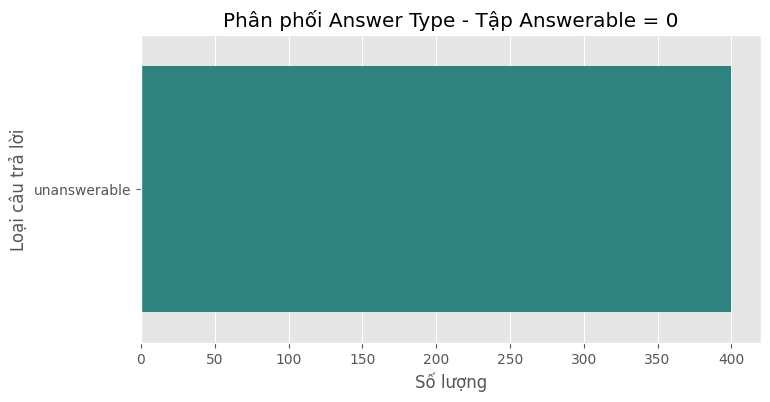

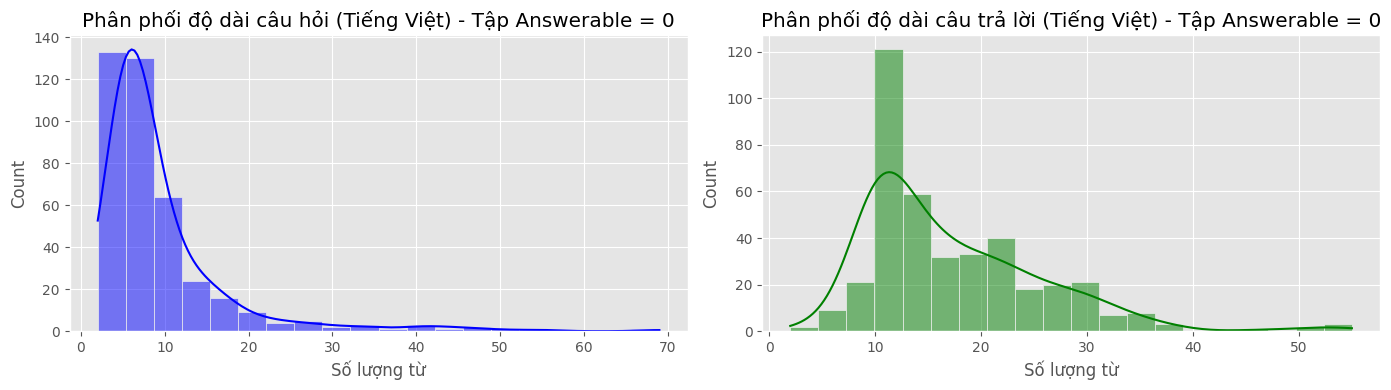


--- Top 10 câu hỏi lặp lại nhiều nhất (Tiếng Việt) ---
question
Món đồ này là gì?                     29
Bạn đọc giúp tôi chữ trên này với.     8
Ngày hết hạn là gì?                    6
Có gì trong hộp này?                   5
Cái chai này là gì?                    4
Đây là loại súp gì?                    4
Trong lon này có gì?                   3
Cái này có mùi vị thế nào?             3
Sản phẩm này là gì?                    3
Cho tôi hỏi đây là vật gì?             3
Name: count, dtype: int64




In [11]:
# 1. Phân tích tập dữ liệu Unanswerable (0)
perform_eda(df_0, title="Tập Answerable = 0")


PHÂN TÍCH TẬP DỮ LIỆU: Tập Answerable = 1



,image,question,answer_type,AI_answer
0,IMG-1-0000001.jpg,Đây là loại cà phê gì?,other,Folgers Classic Roast.
1,IMG-1-0000002.jpg,Có gì bên trong chiếc hộp này vậy?,other,Hộp này chứa sản phẩm bánh lasagne đặc biệt (S...
2,IMG-1-0000003.jpg,Cái này nằm ở đâu?,other,"Hình ảnh này liên quan đến ""Southern Arizona A..."



--- Thông tin chung ---
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 600 entries, 0 to 599
Data columns (total 8 columns):
 #   Column         Non-Null Count  Dtype 
---  ------         --------------  ----- 
 0   image          600 non-null    object
 1   question       600 non-null    object
 2   answers        600 non-null    object
 3   answer_type    600 non-null    object
 4   answerable     600 non-null    int64 
 5   AI_answer      600 non-null    object
 6   question_len   600 non-null    int64 
 7   AI_answer_len  600 non-null    int64 
dtypes: int64(3), object(5)
memory usage: 37.6+ KB
None


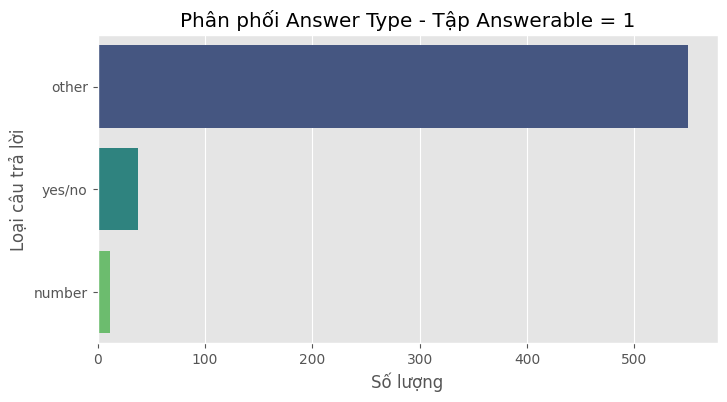

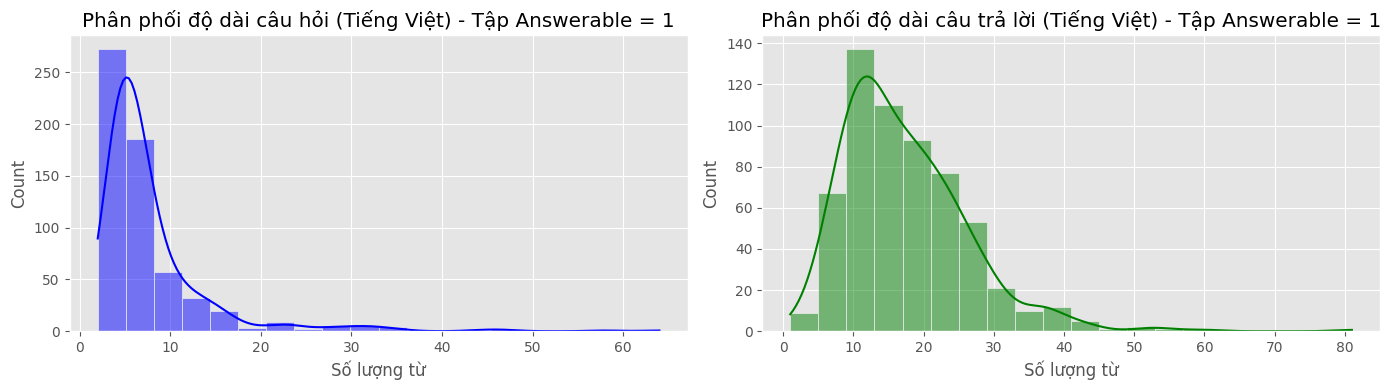


--- Top 10 câu hỏi lặp lại nhiều nhất (Tiếng Việt) ---
question
Đây là vật gì?                        107
Vật này có màu gì vậy?                 11
Vật thể này là gì?                     10
Có gì bên trong chiếc hộp này vậy?      8
Có gì trong chai này?                   6
Đó là cái gì vậy?                       6
Tên của món đồ này là gì?               6
Xin hỏi đây là cái gì?                  6
Dòng chữ này có nghĩa là gì?            6
Màu của chiếc áo này là gì?             5
Name: count, dtype: int64




In [12]:
# 2. Phân tích tập dữ liệu Answerable (1)
perform_eda(df_1, title="Tập Answerable = 1")

## So sánh trực tiếp 2 tập dữ liệu

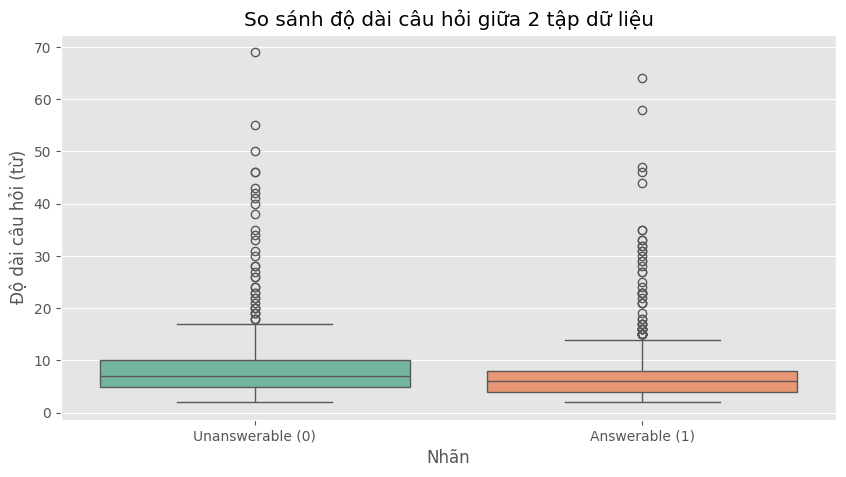

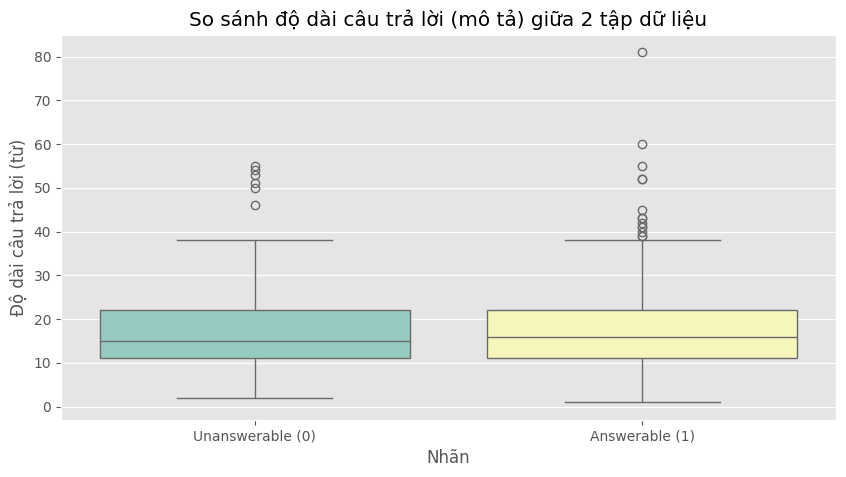

In [13]:
# Gộp dữ liệu để so sánh
df_all = pd.concat([df_0, df_1], ignore_index=True)
df_all['label'] = df_all['answerable'].map({0: 'Unanswerable (0)', 1: 'Answerable (1)'})

# So sánh độ dài câu hỏi
plt.figure(figsize=(10, 5))
sns.boxplot(x='label', y='question_len', data=df_all, palette='Set2')
plt.title('So sánh độ dài câu hỏi giữa 2 tập dữ liệu')
plt.xlabel('Nhãn')
plt.ylabel('Độ dài câu hỏi (từ)')
plt.show()

# So sánh độ dài câu trả lời mô tả
plt.figure(figsize=(10, 5))
sns.boxplot(x='label', y='AI_answer_len', data=df_all, palette='Set3')
plt.title('So sánh độ dài câu trả lời (mô tả) giữa 2 tập dữ liệu')
plt.xlabel('Nhãn')
plt.ylabel('Độ dài câu trả lời (từ)')
plt.show()

In [14]:
def print_length_stats(df, name):
    print(f"--- Thống kê độ dài cho: {name} ---")
    
    # Câu hỏi
    q_len = df['question_len']
    print("Câu hỏi (Tiếng Việt):")
    print(f"  - Ngắn nhất: {q_len.min()} từ")
    print(f"  - Dài nhất: {q_len.max()} từ")
    print(f"  - Trung bình: {q_len.mean():.2f} từ")
    
    # Câu trả lời
    a_len = df['AI_answer_len']
    print("Câu trả lời (Tiếng Việt):")
    print(f"  - Ngắn nhất: {a_len.min()} từ")
    print(f"  - Dài nhất: {a_len.max()} từ")
    print(f"  - Trung bình: {a_len.mean():.2f} từ")
    print("\n")

print_length_stats(df_0, "Tập KHÔNG THỂ trả lời (0)")
print_length_stats(df_1, "Tập CÓ THỂ trả lời (1)")
print_length_stats(df_all, "Toàn bộ dữ liệu")

--- Thống kê độ dài cho: Tập KHÔNG THỂ trả lời (0) ---
Câu hỏi (Tiếng Việt):
  - Ngắn nhất: 2 từ
  - Dài nhất: 69 từ
  - Trung bình: 9.49 từ
Câu trả lời (Tiếng Việt):
  - Ngắn nhất: 2 từ
  - Dài nhất: 55 từ
  - Trung bình: 17.32 từ


--- Thống kê độ dài cho: Tập CÓ THỂ trả lời (1) ---
Câu hỏi (Tiếng Việt):
  - Ngắn nhất: 2 từ
  - Dài nhất: 64 từ
  - Trung bình: 7.89 từ
Câu trả lời (Tiếng Việt):
  - Ngắn nhất: 1 từ
  - Dài nhất: 81 từ
  - Trung bình: 17.29 từ


--- Thống kê độ dài cho: Toàn bộ dữ liệu ---
Câu hỏi (Tiếng Việt):
  - Ngắn nhất: 2 từ
  - Dài nhất: 69 từ
  - Trung bình: 8.53 từ
Câu trả lời (Tiếng Việt):
  - Ngắn nhất: 1 từ
  - Dài nhất: 81 từ
  - Trung bình: 17.30 từ


